# Exploratory Data Analysis (EDA) of Thai Constitution Data

In [91]:
import itertools
import re
from collections import Counter

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pythainlp.corpus.common import thai_stopwords
from pythainlp.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm import tqdm

tqdm.pandas()

sns.set_theme(style='whitegrid')

font_path = '../../static/font/LINESeedSansTH_Rg.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

print('Font set to:', font_prop.get_name())

Font set to: LINE Seed Sans TH


## 1. Data Loading and Cleaning

In [77]:
df = pd.read_csv("../../01_data_preparation/struc-data/csv/all_sections_combined.csv")

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4706 entries, 0 to 4705
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   constitution_id  4706 non-null   str  
 1   year_th          4706 non-null   int64
 2   name_short       4706 non-null   str  
 3   chapter_number   4706 non-null   int64
 4   section_number   4706 non-null   int64
 5   section_text     4706 non-null   str  
dtypes: int64(3), str(3)
memory usage: 220.7 KB


In [79]:
df.nunique()

constitution_id      38
year_th              31
name_short           38
chapter_number       18
section_number      336
section_text       3995
dtype: int64

In [80]:
df

,constitution_id,year_th,name_short,chapter_number,section_number,section_text
0,const_2475,2475,Constitution 2475,0,1,สยามประเทศเป็นราชอาณาจักรอันหนึ่งอันเดียว จะแบ...
1,const_2475,2475,Constitution 2475,0,2,อำนาจอธิปไตยย่อมมาจากปวงชนชาวสยาม พระมหากษัตริ...
2,const_2475,2475,Constitution 2475,1,3,องค์พระมหากษัตริย์ดำรงอยู่ในฐานะอันเป็นที่เคาร...
3,const_2475,2475,Constitution 2475,1,4,พระมหากษัตริย์ต้องทรงเป็นพุทธมามกะ และทรงเป็นอ...
4,const_2475,2475,Constitution 2475,1,5,พระมหากษัตริย์ทรงดำรงตำแหน่งจอมทัพ สยาม
...,...,...,...,...,...,...
4701,const_2564,2564,Constitution 2564,0,6,ในวาระเริ่มแรก มิให้นำบทบัญญัติ
4702,const_2564,2564,Constitution 2564,0,86,และ
4703,const_2564,2564,Constitution 2564,0,91,ของรัฐธรรมนูญแห่งราชอาณาจักรไทย ซึ่งแก้ไขเพิ่ม...
4704,const_2564,2564,Constitution 2564,0,83,และ


In [ ]:
df['has_parentheses'] = df['name_short'].str.contains(r'\(.*?\)')
df[df['has_parentheses']]["name_short"].unique()

<StringArray>
['Constitution 2490 (interim)', 'Constitution 2490 (amended)',
    'Constitution 2491 (No.2)',    'Constitution 2491 (No.3)',
 'Constitution 2534 (interim)',    'Constitution 2535 (No.1)',
    'Constitution 2535 (No.2)',    'Constitution 2535 (No.3)',
    'Constitution 2535 (No.4)', 'Constitution 2549 (interim)',
    'Constitution 2554 (No.1)',    'Constitution 2554 (No.2)',
 'Constitution 2557 (interim)']
Length: 13, dtype: str

In [82]:
df['name_short'] = df['name_short'].str.replace('Constitution', '', regex=False).str.strip()

## 2. Basic Structural EDA

Null values in text: 0


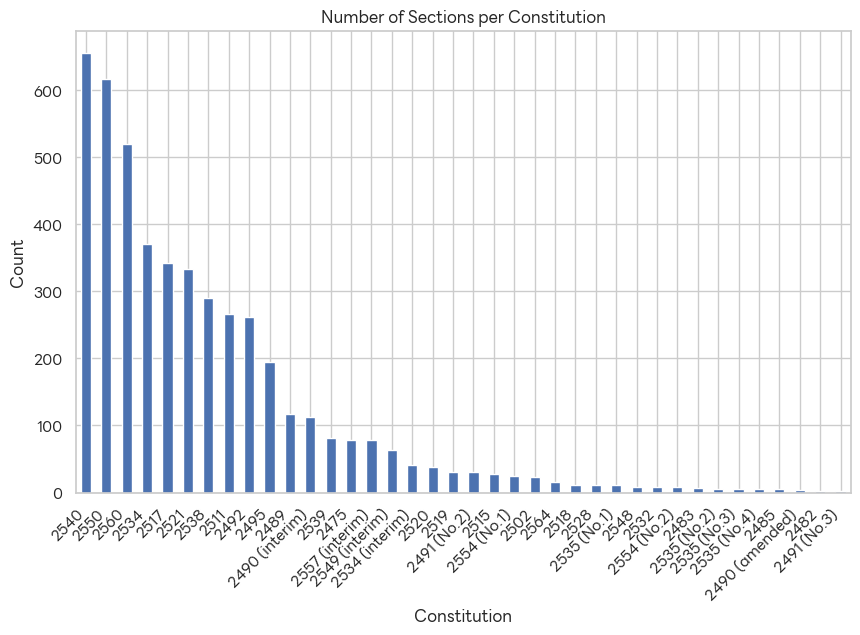

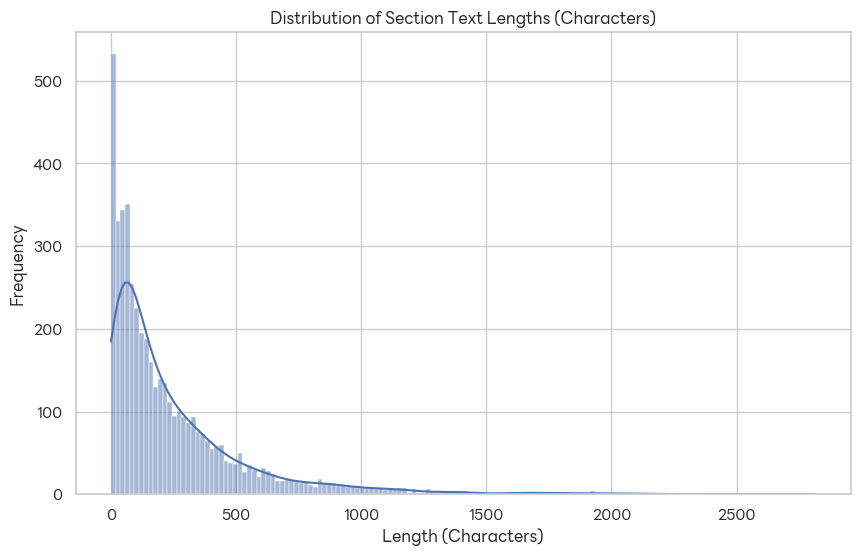

In [89]:
# Fixing the KeyError and checking for nulls
if 'section_text' in df.columns:
    df = df.rename(columns={'section_text': 'text'})

print('Null values in text:', df['text'].isnull().sum())
df = df.dropna(subset=['text'])

# Volume Analysis
sections_per_const = df.groupby('name_short').size().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sections_per_const.plot(kind='bar')
plt.title('Number of Sections per Constitution')
plt.xlabel('Constitution')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

# Text Length Distribution
df['text_length'] = df['text'].str.len()
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=150, kde=True)
plt.title('Distribution of Section Text Lengths (Characters)')
plt.xlabel('Length (Characters)')
plt.ylabel('Frequency')
plt.show()

## 3. Thai Tokenization and Preprocessing

Newmm Token Count: 33
Attacut Token Count: 34
Newmm Samples: ['สยาม', 'ประเทศ', 'เป็น', 'ราชอาณาจักร', 'อัน', 'หนึ่ง', 'อัน', 'เดียว', ' ', 'จะ']
Attacut Samples: ['สยาม', 'ประเทศ', 'เป็น', 'ราชอาณาจักร', 'อัน', 'หนึ่ง', 'อัน', 'เดียว', ' ', 'จะ']


100%|██████████| 4706/4706 [00:40<00:00, 116.44it/s]


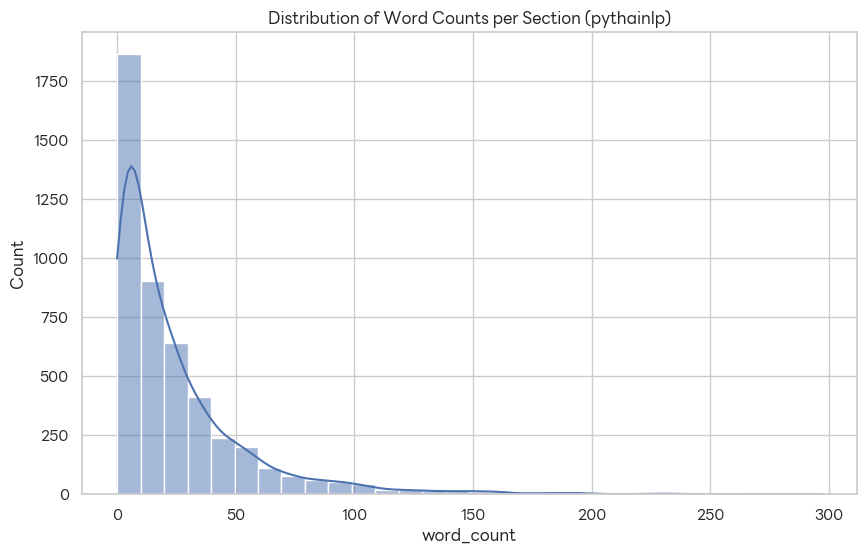

In [92]:
sample_text = df['text'].iloc[0]

tokens_newmm = word_tokenize(sample_text, engine='newmm')
tokens_attacut = word_tokenize(sample_text, engine='attacut')

print(f'Newmm Token Count: {len(tokens_newmm)}')
print(f'Attacut Token Count: {len(tokens_attacut)}')
print('Newmm Samples:', tokens_newmm[:10])
print('Attacut Samples:', tokens_attacut[:10])

stopwords = set(thai_stopwords())

def preprocess_thai(text):
    # tokenize
    tokens = word_tokenize(text, engine='attacut')

    clean_tokens = []
    for t in tokens:
        t = t.strip()
        # skip empty, stopwords, and punctuation
        if (
            t and
            t not in stopwords and
            not re.match(r'^[\W_]+$', t)  # removes punctuation/symbols
        ):
            clean_tokens.append(t)

    return clean_tokens

df['tokens'] = df['text'].progress_apply(preprocess_thai)
df['word_count'] = df['tokens'].dropna().apply(len)

# Visualize Word Counts
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'].dropna(), bins=30, kde=True)
plt.title('Distribution of Word Counts per Section (pythainlp)')
plt.show()

## 4. Bag-of-Words (BoW) Analysis

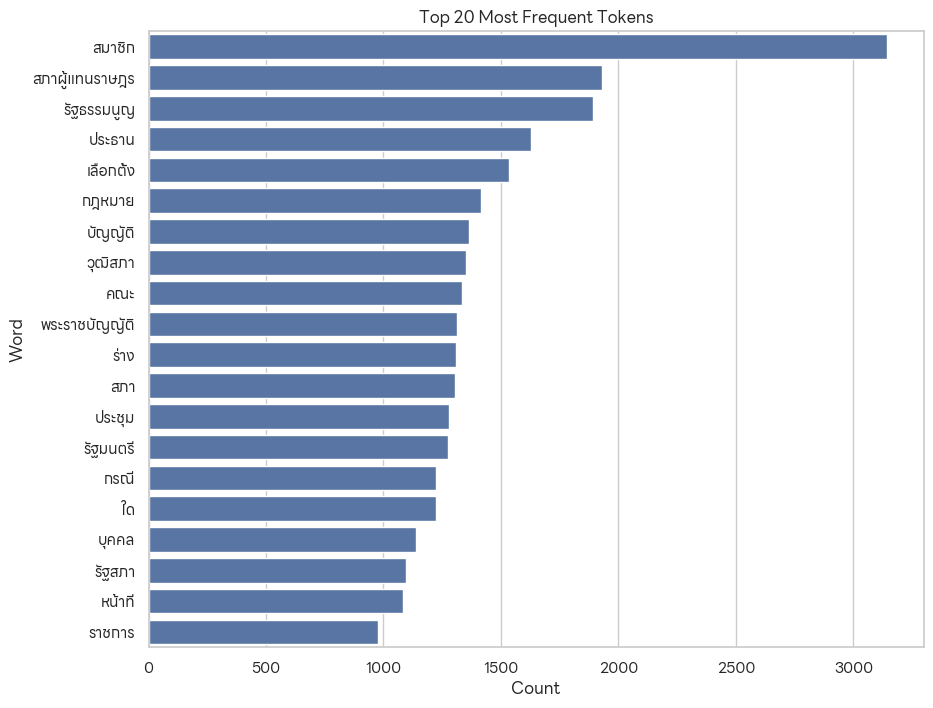

In [93]:
all_tokens = list(itertools.chain.from_iterable(df['tokens'].dropna()))
token_counts = Counter(all_tokens)

top_bow_df = pd.DataFrame(token_counts.most_common(20), columns=['Word', 'Count'])

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Count', y='Word', data=top_bow_df)
plt.title('Top 20 Most Frequent Tokens')
plt.show()

## 5. N-Gram Analysis

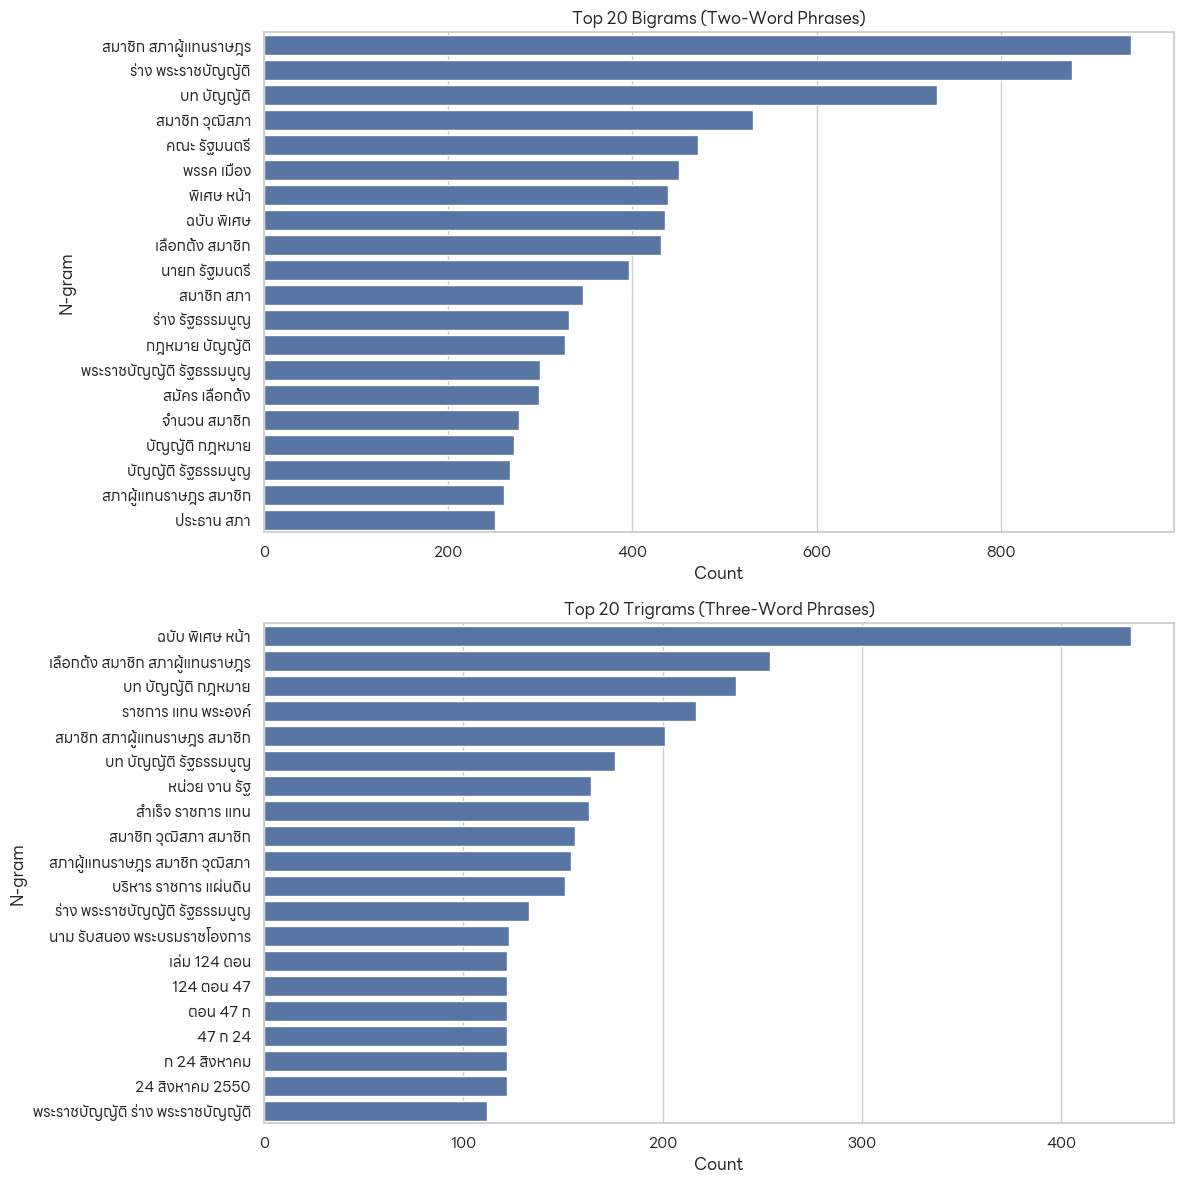

In [94]:
def get_top_ngrams(corpus, n=None, top_k=20):
    # corpus is a list of tokenized words
    # Flatten list
    flat_list = [item for sublist in corpus.dropna() for item in sublist]
    # create n-grams manually
    ngrams_list = [' '.join(flat_list[i:i+n]) for i in range(len(flat_list)-n+1)]
    return Counter(ngrams_list).most_common(top_k)

# Get top 20 bigrams
top_20_bigrams = get_top_ngrams(df['tokens'], n=2, top_k=20)
top_20_bigrams_df = pd.DataFrame(top_20_bigrams, columns=['N-gram', 'Count'])

# Get top 20 trigrams
top_20_trigrams = get_top_ngrams(df['tokens'], n=3, top_k=20)
top_20_trigrams_df = pd.DataFrame(top_20_trigrams, columns=['N-gram', 'Count'])

# Plot
plt.figure(figsize=(12, 12))

plt.subplot(2, 1, 1)
sns.barplot(x='Count', y='N-gram', data=top_20_bigrams_df)
plt.title('Top 20 Bigrams (Two-Word Phrases)')

plt.subplot(2, 1, 2)
sns.barplot(x='Count', y='N-gram', data=top_20_trigrams_df)
plt.title('Top 20 Trigrams (Three-Word Phrases)')

plt.tight_layout()
plt.show()

## 6. TF-IDF Analysis

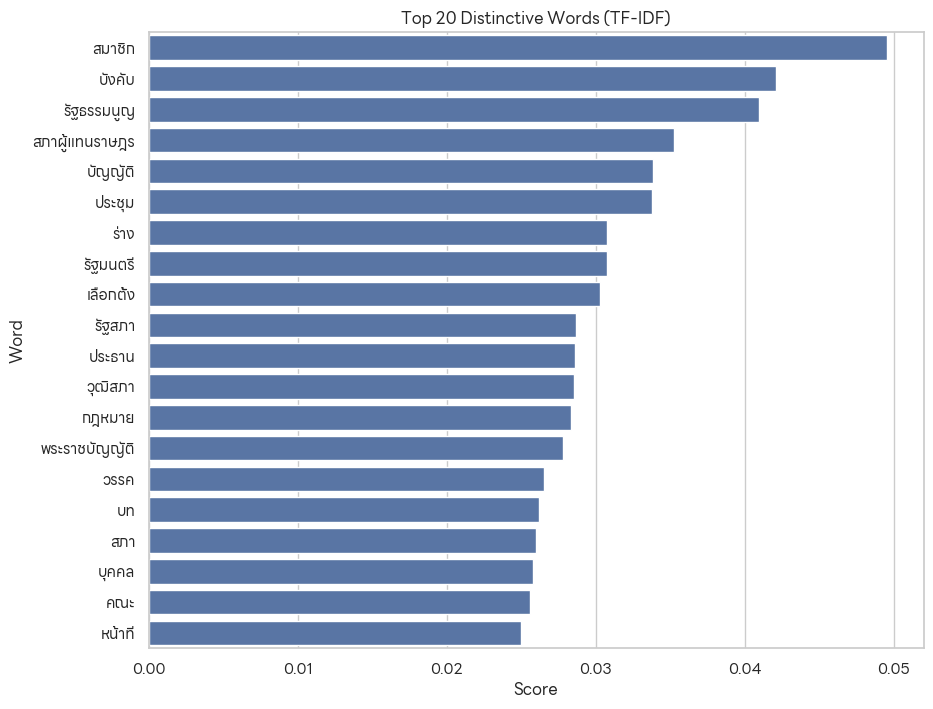

In [96]:
df_tfidf = df.dropna(subset=['tokens']).copy()

# Vectorization
vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    token_pattern=None
)
tfidf_matrix = vectorizer.fit_transform(df_tfidf['tokens'])
feature_names = vectorizer.get_feature_names_out()

feature_names = vectorizer.get_feature_names_out()

def get_top_tfidf_words(matrix, feature_names, top_n=10):
    mean_scores = np.asarray(matrix.mean(axis=0)).flatten()
    top_indices = mean_scores.argsort()[-top_n:][::-1]
    return [(feature_names[i], mean_scores[i]) for i in top_indices]

top_keywords = get_top_tfidf_words(tfidf_matrix, feature_names, top_n=20)
top_keywords_df = pd.DataFrame(top_keywords, columns=['Word', 'Score'])

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Score', y='Word', data=top_keywords_df)
plt.title('Top 20 Distinctive Words (TF-IDF)')
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display


# Function to compute and plot TF-IDF n-grams
def plot_tfidf_ngrams(n=2, top_n=20):
    vectorizer = TfidfVectorizer(
        tokenizer=lambda x: x,
        preprocessor=lambda x: x,
        token_pattern=None,
        ngram_range=(n, n),
        min_df=2  # optional: reduce noise
    )

    tfidf_matrix = vectorizer.fit_transform(df_tfidf['tokens'])
    feature_names = vectorizer.get_feature_names_out()

    # Compute mean TF-IDF scores
    mean_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    top_indices = mean_scores.argsort()[-top_n:][::-1]

    top_terms = [(feature_names[i], mean_scores[i]) for i in top_indices]
    top_df = pd.DataFrame(top_terms, columns=['N-gram', 'Score'])

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Score', y='N-gram', data=top_df)
    plt.title(f'Top {top_n} TF-IDF {n}-grams')
    plt.show()

# Slider widget
slider = widgets.IntSlider(
    value=2,
    min=1,
    max=10,
    step=1,
    description='n-gram:',
    continuous_update=False
)

# Link slider to function
widgets.interactive(plot_tfidf_ngrams, n=slider)

interactive(children=(IntSlider(value=2, continuous_update=False, description='n-gram:', max=10, min=1), IntSl…